# Network Intrusion Detection System using Machine Learning

# 1. Problem Statement

This project focuses on binary classification of network traffic into normal and attack categories. The objective is to build a machine learning based intrusion detection system that can accurately detect malicious network activities and improve network security.

---

# 2. Dataset Selection

The NSL-KDD dataset is used for this project. It is an improved version of the KDD Cup 1999 dataset and removes redundant records, providing better evaluation for machine learning models.

The dataset contains network traffic data with multiple attack categories such as DoS, Probe, R2L, and U2R. For this project, the problem is simplified into binary classification where normal traffic is labeled as 0 and all attack types are labeled as 1.

---

# 3. Data Preprocessing

Label cleaning is performed by removing unwanted characters and converting labels into binary format.

One hot encoding is applied to categorical features such as protocol type, service, and flag to convert them into numerical format.

Constant columns are removed to eliminate features with no variation.

Correlation based feature removal is applied to reduce multicollinearity by removing highly correlated features.

Mutual information is used for feature selection to identify the most relevant features contributing to classification.

Feature scaling is applied using standard scaler for models that require normalized input such as SVM and Logistic Regression.

---

# 4. Libraries Used and Justification

pandas is used for data manipulation and handling structured data.

numpy is used for numerical computations.

scikit-learn is used for implementing machine learning algorithms, preprocessing, and evaluation metrics.

matplotlib and seaborn are used for data visualization and plotting graphs.

urllib is used for downloading the dataset.

---

# 5. Algorithms Used

Naive Bayes is a probabilistic model based on Bayes theorem.

Decision Tree is a rule based model that splits data based on feature values.

Random Forest is an ensemble method that combines multiple decision trees for improved performance.

Support Vector Machine is a margin based classifier that separates classes using hyperplanes.

Logistic Regression is a linear model used for binary classification.

Gradient Boosting is an ensemble technique that builds models sequentially to correct errors.

---

# 6. Mathematical Formulas

Logistic Regression  
P(y=1|x) = 1 / (1 + exp(-z))

Naive Bayes  
P(A|B) = (P(B|A) * P(A)) / P(B)

Entropy  
Entropy = - sum(p * log2(p))

Random Forest  
Prediction is based on majority voting of multiple trees

ROC AUC  
Represents the area under the curve between true positive rate and false positive rate

---

## 7. Architecture

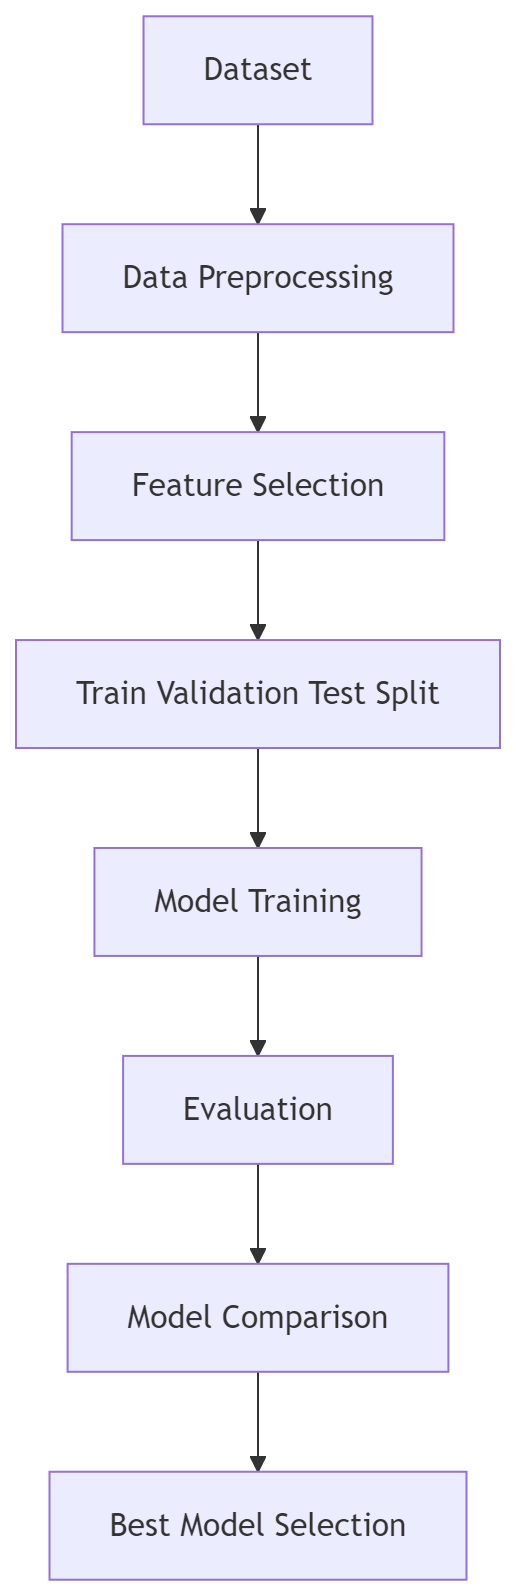


In [3]:
# ============================================
# 1. Imports
# ============================================
import pandas as pd
import numpy as np
import urllib.request
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight

In [4]:
# ============================================
# 2. Download Dataset
# ============================================
url = "https://raw.githubusercontent.com/sivasaigajula/KDD-Cup-1999-dataset-Analysis/main/data/KDDTrain+.txt"
file_name = "kdd_data.csv"
urllib.request.urlretrieve(url, file_name)

# ============================================
# 3. Load Dataset
# ============================================
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

df = pd.read_csv(file_name, names=columns)

# Safe drop
df.drop("difficulty", axis=1, inplace=True, errors='ignore')

print("Dataset Shape:", df.shape)
print("\nAttack Distribution:\n", df['label'].value_counts())

Dataset Shape: (125973, 42)

Attack Distribution:
 label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [5]:
# ============================================
# 4. Preprocessing
# ============================================
df['label'] = df['label'].astype(str).str.rstrip('.').apply(
    lambda x: 0 if x == 'normal' else 1
)

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=['protocol_type', 'service', 'flag'],
    drop_first=True
)

# Remove constant columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_cols, inplace=True, errors='ignore')

# Correlation removal
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['label'], errors='ignore')
corr = numeric_df.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

df.drop(columns=to_drop, inplace=True, errors='ignore')

In [6]:
# ============================================
# 5. Split
# ============================================
X = df.drop('label', axis=1)
y = df['label']

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

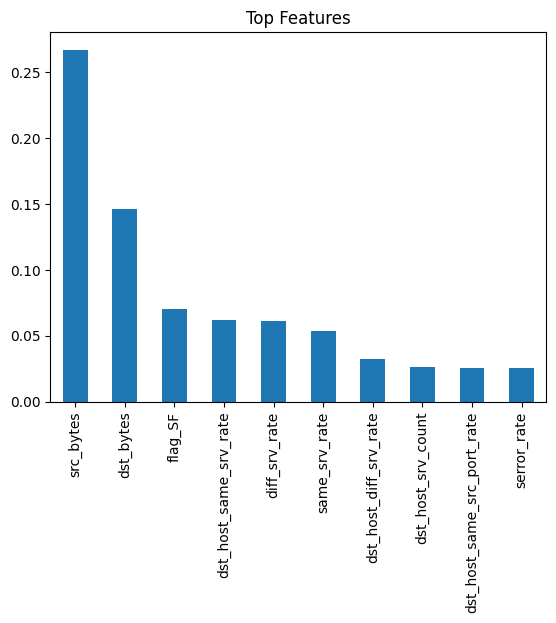

In [7]:
# ============================================
# 6. Feature Selection
# ============================================
mi_scores = mutual_info_classif(X_train_full, y_train_full, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_full.columns)

top_features = mi_series.sort_values(ascending=False).head(30).index

X_train = X_train_full[top_features]
X_val = X_val[top_features]
X_test = X_test[top_features]

# Feature importance plot (fixed)
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(X_train, y_train_full)

pd.Series(rf_selected.feature_importances_, index=top_features)\
    .sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Features")
plt.show()

In [8]:
# ============================================
# 7. Scaling
# ============================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [9]:
# ============================================
# 8. Models
# ============================================
models = {
    "Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        class_weight='balanced',
        random_state=42
    ),

    "SVM": SVC(
        kernel='linear',
        class_weight='balanced'
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    ),

    "Gradient Boosting": HistGradientBoostingClassifier(
        random_state=42
    )
}


In [10]:
# ============================================
# 9. Training
# ============================================
results = {}
roc_scores = {}
roc_curves = {}
trained_models = {}
val_scores = {}

sample_weights = compute_sample_weight('balanced', y_train_full)

for name, model in models.items():

    print(f"\n========== {name} ==========")

    if name in ["SVM", "Logistic Regression"]:
        X_tr, X_te = X_train_scaled, X_test_scaled
        X_val_use = X_val_scaled
    else:
        X_tr, X_te = X_train, X_test
        X_val_use = X_val

    if name == "Gradient Boosting":
        model.fit(X_tr, y_train_full, sample_weight=sample_weights)
    else:
        model.fit(X_tr, y_train_full)

    trained_models[name] = model

    # Validation
    y_val_pred = model.predict(X_val_use)
    val_scores[name] = accuracy_score(y_val, y_val_pred)
    print("Validation Accuracy:", val_scores[name])

    # Test
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Test Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    try:
        if name == "SVM":
            y_scores = model.decision_function(X_te)
            roc = roc_auc_score(y_test, y_scores)
            roc_curves[name] = y_scores
        else:
            y_prob = model.predict_proba(X_te)[:, 1]
            roc = roc_auc_score(y_test, y_prob)
            roc_curves[name] = y_prob

        roc_scores[name] = roc
        print("ROC-AUC:", roc)

    except Exception as e:
        print(f"{name} ROC error:", e)
        roc_scores[name] = 0
        roc_curves[name] = None


========== Naive Bayes ==========
Validation Accuracy: 0.5343458933107536
Test Accuracy: 0.5342400508044031
              precision    recall  f1-score   support

           0       0.53      0.98      0.69     10102
           1       0.49      0.02      0.03      8794

    accuracy                           0.53     18896
   macro avg       0.51      0.50      0.36     18896
weighted avg       0.51      0.53      0.39     18896

Confusion Matrix:
 [[9949  153]
 [8648  146]]
ROC-AUC: 0.9169063003351713

========== Decision Tree ==========
Validation Accuracy: 0.9968247248094835
Test Accuracy: 0.9969834885690093
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10102
           1       1.00      0.99      1.00      8794

    accuracy                           1.00     18896
   macro avg       1.00      1.00      1.00     18896
weighted avg       1.00      1.00      1.00     18896

Confusion Matrix:
 [[10094     8]
 [   49  8745]]
RO

In [11]:
# ============================================
# 10. Cross Validation
# ============================================
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

cv_scores = cross_val_score(rf, X_train, y_train_full, cv=5)

print("\nCross-Validation Accuracy:", cv_scores.mean())


Cross-Validation Accuracy: 0.9982309202931996


In [12]:
# ============================================
# 11. Model Selection (Validation Based)
# ============================================
best_model = max(val_scores, key=val_scores.get)

print("\nBest Model (Validation):", best_model)


Best Model (Validation): Random Forest


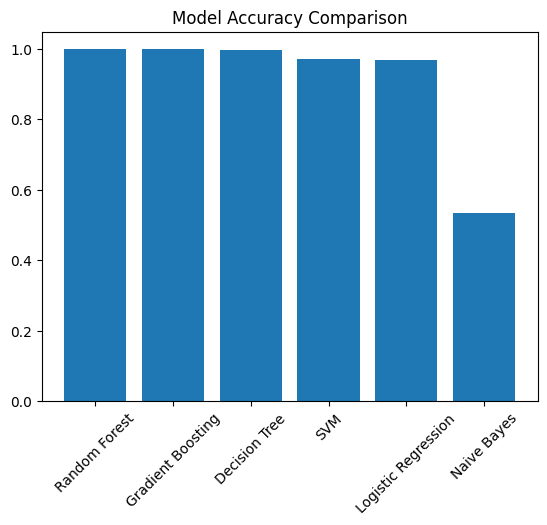

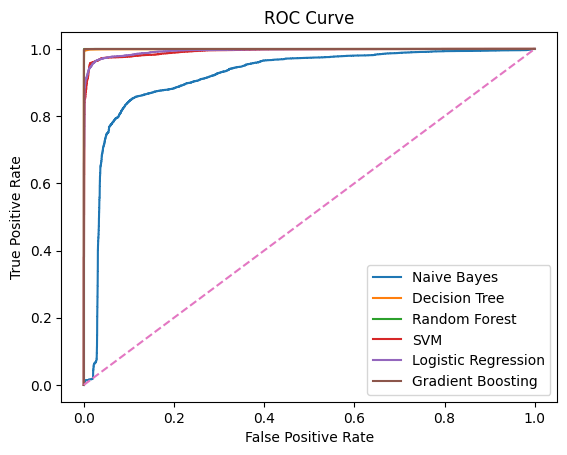

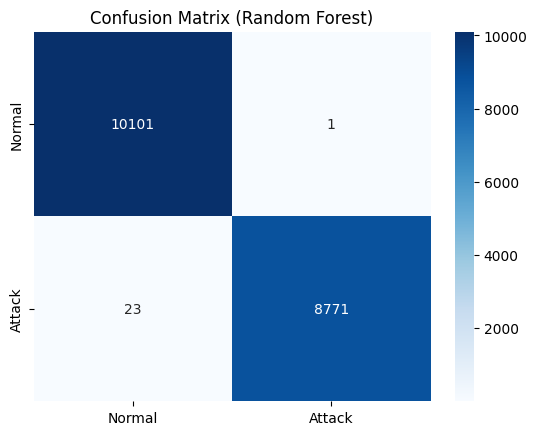

In [13]:
# ============================================
# 12. Graphs
# ============================================

# Accuracy Comparison
sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

plt.figure()
plt.bar(sorted_results.keys(), sorted_results.values())
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()

# ROC Curve
plt.figure()

for name, y_prob in roc_curves.items():
    if y_prob is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()
plt.show()

# Confusion Matrix (Best Model)
best_model_obj = trained_models[best_model]

if best_model in ["SVM", "Logistic Regression"]:
    X_te_best = X_test_scaled
else:
    X_te_best = X_test

y_pred_best = best_model_obj.predict(X_te_best)

sns.heatmap(
    confusion_matrix(y_test, y_pred_best),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal','Attack'],
    yticklabels=['Normal','Attack']
)

plt.title(f"Confusion Matrix ({best_model})")
plt.show()

# ============================================
# NOTE
# ============================================
# High accuracy is due to strong feature separability in NSL-KDD dataset
# Model trained on static dataset and may require updates for real-time usage

---

# 9. Optimization Techniques Used

Stratified sampling is used to maintain class distribution.

Feature selection using mutual information reduces dimensionality.

Highly correlated features are removed to improve model performance.

Class imbalance is handled using class weights.

Tree depth is limited to reduce overfitting.

Cross validation is used to ensure model generalization.

---

# 10. Model Comparison

| Model | Validation Accuracy | Test Accuracy | ROC AUC |
|------|--------------------|--------------|---------|
| Naive Bayes | 0.53 | 0.53 | 0.91 |
| Decision Tree | 0.996 | 0.997 | 0.999 |
| Random Forest | 0.998 | 0.998 | 1.00 |
| SVM | 0.97 | 0.97 | 0.99 |
| Logistic Regression | 0.96 | 0.96 | 0.99 |
| Gradient Boosting | 0.998 | 0.998 | 0.999 |


Note :
Random Forest is the best performing model as it achieves the highest accuracy and ROC-AUC while maintaining consistent validation and test performance.

Gradient Boosting also performs similarly well, but Random Forest is preferred due to its robustness and stability.

---

# 11. Evaluation and Validation

The dataset is split into training, validation, and test sets.

The validation set is used for model comparison and selection to avoid bias.

Cross validation is applied on the training data to ensure the model generalizes well.

ROC AUC is used along with accuracy to evaluate performance, especially for imbalanced data.

---

# 12. Feature Importance Interpretation

The most important features include src_bytes, dst_bytes, and flag related features.

These features represent network traffic behavior such as data transfer size and connection status, which are strong indicators of intrusion.

---

# 13. Analysis

Naive Bayes performs poorly due to its assumption of feature independence. Network features are highly correlated, which violates this assumption.

Tree based models such as Random Forest and Gradient Boosting achieve very high accuracy due to strong feature separability.

Support Vector Machine and Logistic Regression provide stable and balanced performance.

ROC AUC is preferred over accuracy as it provides better evaluation for imbalanced datasets.

---

# 14. Advantages

High accuracy in detecting intrusions.

Robust preprocessing pipeline.

Effective handling of class imbalance.

Multiple models evaluated for comparison.

Cross validation ensures reliability.

---

# 15. Limitations

The model is trained on a static dataset and may not generalize directly to real time network traffic.

It may require retraining and adaptation for deployment in real world environments.

---

# 16. Conclusion

The project successfully develops a network intrusion detection system using machine learning.

Random Forest is identified as the best performing model due to its high accuracy, robustness, and generalization capability.

The system demonstrates strong performance and can be extended for real time applications.

---

# 17. Additional Creativity and Innovation

Train validation test split is implemented for better evaluation.

Cross validation is applied to ensure robustness.

Feature importance and mutual information are used for feature selection.

Visualization techniques such as accuracy comparison, ROC curve, and confusion matrix are included.

Advanced preprocessing techniques such as correlation removal and constant feature removal are applied.
